# Exploratory Phage Genomics Workflow

### Project Overview

This notebook documents a small, reproducible bioinformatics workflow centered on Garey24, a bacteriophage isolated within the SEA-PHAGES program at the Universidad Nacional de Rosario. During my time as a microbiology instructor, I supervised undergraduate students in soil-derived phage isolation, plaque purification, and basic phage handling, and helped process 43 environmental soil samples that yielded 24 phage-positive isolates. Garey24 was selected from this collection for sequencing and annotation and serves here as the starting point for a small comparative genomics workflow.

The goal of this notebook is to retrieve GenBank records, screen them for annotation keywords associated with lysogeny or virulence, and compare a conserved structural protein across a small set of phages.

This project is intended as an exploratory bioinformatics exercise rather than a therapeutic development workflow.

### Objectives

1. Automated Ingestion:
   Programmatic retrieval of target phage genomes from the NCBI GenBank database.

2. Safety-Oriented Screening:
   Annotation-based screening for genes associated with lysogeny, virulence, or other undesirable features.

3. Comparative Analysis:
   Pairwise comparison of a conserved structural protein to estimate similarity among selected phages.

4. Data Visualization:
   Generation of identity matrices, heatmaps, and hierarchical clustering visualizations.

### Objective 1 – Automated Ingestion
#### Phase 1.1 – Automated Genome Acquisition

The first step of the workflow consists of programmatically retrieving phage genome records from the NCBI GenBank database using Biopython's Entrez module.

To create a small but informative dataset, the collection combines the SEA-PHAGES isolate Garey24 with several reference actinophages. The panel includes both phages expected to pass downstream screening steps and phages known to contain lysogeny-associated annotations. This allows the filtering stage to be evaluated using internal positive and negative controls.

All records are downloaded in GenBank format, preserving both sequence data and functional annotations required for subsequent analysis.

In [ ]:
import os
from Bio import Entrez

# Email to identify yourself to NCBI's API
Entrez.email = "your_email@example.com" 

def download_phage_genome(accession_id, output_filename):
    """
    Retrieves a GenBank record from the NCBI Nucleotide database
    and stores it locally for downstream analysis.
    """
    if os.path.exists(output_filename):
        print(f"[-] File '{output_filename}' already exists locally. Skipping download.")
        return
    
    print(f"[+] Connecting to NCBI to fetch Phage Accession: {accession_id}...")
    try:
        # Fetching data from 'nucleotide' database in text format as a GenBank record
        with Entrez.efetch(db="nucleotide", id=accession_id, rettype="gb", retmode="text") as handle:
            with open(output_filename, "w") as out_file:
                out_file.write(handle.read())
        print(f"[✔] Successfully saved: {output_filename}")
    except Exception as e:
        print(f"[✘] Error downloading {accession_id}: {e}")

# Define the phages included in this comparative genomics exercise
# Garey24 (SEA-PHAGES isolate) plus selected reference actinophages

# The dataset combines the SEA-PHAGES isolate Garey24 with a small set
# of reference actinophages. Some phages are expected to pass the
# screening workflow, while others contain known lysogeny-associated
# annotations and serve as internal controls for the filtering step.

target_phages = {
    "Garey24_phage": "OR521084",
    "phiPA3_phage": "NC_028942",

    "TM4_phage": "NC_004687",
    "Bxz1_phage": "NC_004689",

    "Chako_phage": "OP867023",
    "Erla_phage": "MW291026",

    "D29_phage": "NC_001900",
    "L5_phage": "NC_001335"
}

print("=== Executing Unified Actinophage Dataset Acquisition ===")

# Download all selected GenBank records locally for subsequent analysis
for phage_name, acc_id in target_phages.items():
    destination_file = f"{phage_name}_{acc_id}.gb"
    download_phage_genome(acc_id, destination_file)

=== Executing Unified Actinophage Dataset Acquisition ===
[-] File 'Garey24_phage_OR521084.gb' already exists locally. Skipping download.
[-] File 'phiPA3_phage_NC_028942.gb' already exists locally. Skipping download.
[-] File 'TM4_phage_NC_004687.gb' already exists locally. Skipping download.
[-] File 'Bxz1_phage_NC_004689.gb' already exists locally. Skipping download.
[-] File 'Chako_phage_OP867023.gb' already exists locally. Skipping download.
[-] File 'Erla_phage_MW291026.gb' already exists locally. Skipping download.
[-] File 'D29_phage_NC_001900.gb' already exists locally. Skipping download.
[-] File 'L5_phage_NC_001335.gb' already exists locally. Skipping download.


#### Phase 1.2 – GenBank Record Inspection

Before performing any downstream analysis, the downloaded GenBank record is loaded and inspected to verify successful data acquisition and to explore its basic structure.

This step confirms that sequence data, metadata, and genomic feature annotations are available for subsequent screening and comparative analyses. Using a single phage (Garey24) as an example also provides an opportunity to familiarize ourselves with the organization of a GenBank record before scaling the workflow to multiple genomes.

In [49]:
from Bio import SeqIO

# Define the local path to the downloaded GenBank file for Garey24
garey24_file = "Garey24_phage_OR521084.gb"

# Load and parse the GenBank record using SeqIO
with open(garey24_file, "r") as handle:
    # SeqIO.read is used when the file contains exactly ONE genomic record
    phage_record = SeqIO.read(handle, "genbank")

# Display basic metadata and annotation statistics

print("=== Phage Genomic Metadata Inspection ===")
print(f"Accession ID: {phage_record.id}")
print(f"Phage Name:   {phage_record.name}")
print(f"Description:  {phage_record.description}")
print(f"Genome Size:  {len(phage_record.seq)} bp")
print(f"Total Genomic Features: {len(phage_record.features)}")

=== Phage Genomic Metadata Inspection ===
Accession ID: OR521084.1
Phage Name:   OR521084
Description:  Microbacterium phage Garey24, complete genome
Genome Size:  41522 bp
Total Genomic Features: 127


#### Phase 1.3 – Feature Parsing and Protein-Coding Gene Extraction

GenBank records contain a variety of annotated genomic features, including coding sequences (CDS), regulatory regions, and metadata annotations. Since the downstream analyses focus on phage proteins, the first step is to isolate all protein-coding genes from the complete feature collection.

This section extracts every CDS annotation and inspects a small subset of proteins to verify that functional annotations and amino acid translations are available for subsequent screening and comparative analyses.


In [50]:
# Initialize an empty list to store only the protein-coding features (CDS)
cds_features = []

# Loop through all genomic features to filter by type "CDS"
for feature in phage_record.features:
    if feature.type == "CDS":
        cds_features.append(feature)

# Display the total number of annotated coding sequences
print("=== Genomic Features Filtering ===")
print(f"Total protein-coding genes (CDS) found: {len(cds_features)}")

print("\n=== Sample of the First 3 Target Proteins ===")
# Inspect the first 3 proteins to understand their internal structure
for i, cds in enumerate(cds_features[:3]):
    # Retrieve functional annotation and translated protein sequence
    # Qualifier values are stored as lists, therefore the first element is selected
    
    product_name = cds.qualifiers.get('product', ['Unknown Function'])[0]
    protein_seq = cds.qualifiers.get('translation', ['No translation available'])[0]
    
    print(f"\nProtein #{i+1}:")
    print(f"  - Product:     {product_name}")
    print(f"  - Translation: {protein_seq[:20]}... (Total Length: {len(protein_seq)} aa)")

=== Genomic Features Filtering ===
Total protein-coding genes (CDS) found: 63

=== Sample of the First 3 Target Proteins ===

Protein #1:
  - Product:     hypothetical protein
  - Translation: MCKSHGGGTAASLRASKRAQ... (Total Length: 172 aa)

Protein #2:
  - Product:     terminase
  - Translation: MSTSLLDSEFKEYTFEEVEA... (Total Length: 466 aa)

Protein #3:
  - Product:     portal protein
  - Translation: MTEMNKLQSHLLLQKSPTYT... (Total Length: 465 aa)


### Objective 2 – Safety-Oriented Screening

#### Phase 2.1 – Annotation-Based Safety Screening (Single Genome Example)

A common consideration in phage characterization is the identification of functions associated with lysogeny, virulence, or other potentially undesirable traits.

To illustrate the screening strategy, the Garey24 genome is first analyzed individually. Annotated protein products are searched for a predefined set of keywords associated with integrases, repressors, toxins, resistance determinants, and other functions that may warrant further investigation.

This approach is intentionally simple and relies entirely on existing GenBank annotations. It should therefore be considered a first-pass screening strategy rather than a comprehensive functional assessment.

The purpose of this initial step is to validate the screening logic and inspect the resulting annotations before applying the workflow to a larger collection of reference phages.


In [51]:
# Define keywords associated with lysogeny, virulence, or other potentially undesirable functions
blacklist = ["integrase", "repressor", "excisionase", "toxin", "resistance", "virulence"]

# Initialize a list to store CDS annotations matching blacklist keywords
flagged_genes = []

print("=== Running Safety Screening ===")

# Scan each isolated protein-coding gene
for cds in cds_features:
    # Normalize text to lowercase to prevent casing mismatches (e.g., 'Integrase' vs 'integrase')
    product_name = cds.qualifiers.get('product', ['Unknown Function'])[0].lower()
    locus_tag = cds.qualifiers.get('locus_tag', ['Unknown_Locus'])[0]
    
    # Search the annotation for any keyword present in the blacklist
    for keyword in blacklist:
        if keyword in product_name:
            flagged_genes.append({
                "locus": locus_tag,
                "product": product_name,
                "trigger": keyword
            })

# Generate a screening outcome based on annotation matches
if len(flagged_genes) == 0:
    print("\n[✔] SCREENING RESULT: No flagged annotations detected")
    print(f"No virulence, resistance, or lysogeny markers detected across all {len(cds_features)} genes.")
    print("No blacklist keywords were identified among the annotated CDS features.")
else:
    print(f"\n[✘] SCREENING RESULT: REJECTED")
    print(f"Flagged annotations detected: {len(flagged_genes)}")
    for alert in flagged_genes:
        print(f"  ⚠ Locus: {alert['locus']} | Product: '{alert['product']}' (Trigger: {alert['trigger']})")

=== Running Safety Screening ===

[✔] SCREENING RESULT: No flagged annotations detected
No virulence, resistance, or lysogeny markers detected across all 63 genes.
No blacklist keywords were identified among the annotated CDS features.


#### Phase 2.2 – Batch Screening of Reference Phages

After validating the screening logic on the Garey24 genome, the workflow is extended to a small panel of reference phages.

This step demonstrates how the same annotation-based filtering strategy can be applied automatically across multiple genomes. The dataset intentionally includes phages known to contain lysogeny-associated annotations, allowing the screening procedure to be evaluated using internal positive and negative controls.

The output of this phase is a structured pass/fail report for each phage based on the presence or absence of blacklist keyword matches within annotated coding sequences.


In [52]:
from Bio import SeqIO

def evaluate_phage_safety(genbank_path, target_blacklist=None):
    """
    Annotation-based screening workflow.

    Parses a GenBank record, extracts CDS features,
    and searches for annotations associated with lysogeny,
    virulence, or other undesirable functions.
    """
    # Use the default keyword list if no custom blacklist is provided
    if target_blacklist is None:
        target_blacklist = ["integrase", "repressor", "excisionase", "toxin", "resistance", "virulence"]
    
    # 1. Secure ingestion using Context Manager
    with open(genbank_path, "r") as handle:
        record = SeqIO.read(handle, "genbank")
        
    # 2. Extract and filter protein-coding sequences (CDS)
    cds_features = [f for f in record.features if f.type == "CDS"]
    
    # 3. Search CDS annotations for blacklist keywords
    flagged_genes = []
    for cds in cds_features:
        product_name = cds.qualifiers.get('product', ['Unknown Function'])[0].lower()
        locus_tag = cds.qualifiers.get('locus_tag', ['Unknown_Locus'])[0]
        
        for keyword in target_blacklist:
            if keyword in product_name:
                flagged_genes.append({
                    "locus": locus_tag,
                    "product": product_name,
                    "trigger": keyword
                })
                
    # 4. Generate structured report output
    phage_name = record.name
    total_cds = len(cds_features)
    
    print(f"\n--- Genomics Report: {phage_name} ---")
    print(f"File processed: {genbank_path}")
    print(f"Total Proteins Evaluated: {total_cds}")
    
    if len(flagged_genes) == 0:
        print("[✔] SCREENING RESULT: No flagged annotations detected")
        print("    No blacklist keywords detected among annotated CDS features.")
        return True
    else:
        print(f"[✘] STATUS: FLAGGED. Found {len(flagged_genes)} annotation matches:")
        for alert in flagged_genes:
            print(f"    ⚠ Locus: {alert['locus']} | Product: '{alert['product']}' (Trigger: {alert['trigger']})")
        return False

In [53]:
import glob

print("=== Automated Phage QC Platform: Batch Processing ===")

# 1. Automatically discover all GenBank files in the current directory
phage_files = glob.glob("*.gb")

print(f"Discovering genomic assets... Found {len(phage_files)} phage(s) ready for analysis.\n")

# Store genomes that pass the annotation-based screening step
approved_phages = []

# 2. Apply the screening workflow to each discovered GenBank file
for file_path in phage_files:
    # Execute the function we built in the previous step
    is_safe = evaluate_phage_safety(file_path)
    
    # Track the operational outcome in the logs
    if is_safe:
        print(f"--> LOG: File '{file_path}' successfully validated and queued for alignment.")
        approved_phages.append(file_path) # Store approved genomes for downstream comparative analysis
    else:
        print(f"--> LOG: ALERT! File '{file_path}' failed safety protocols.")
    print("-" * 50)

print(f"\n[✔] BATCH PROCESS COMPLETE: {len(approved_phages)} dynamic assets stored in 'approved_phages'.")

=== Automated Phage QC Platform: Batch Processing ===
Discovering genomic assets... Found 8 phage(s) ready for analysis.


--- Genomics Report: NC_004689 ---
File processed: Bxz1_phage_NC_004689.gb
Total Proteins Evaluated: 109
[✔] SCREENING RESULT: No flagged annotations detected
    No blacklist keywords detected among annotated CDS features.
--> LOG: File 'Bxz1_phage_NC_004689.gb' successfully validated and queued for alignment.
--------------------------------------------------

--- Genomics Report: OP867023 ---
File processed: Chako_phage_OP867023.gb
Total Proteins Evaluated: 62
[✔] SCREENING RESULT: No flagged annotations detected
    No blacklist keywords detected among annotated CDS features.
--> LOG: File 'Chako_phage_OP867023.gb' successfully validated and queued for alignment.
--------------------------------------------------

--- Genomics Report: NC_001900 ---
File processed: D29_phage_NC_001900.gb
Total Proteins Evaluated: 77
[✘] STATUS: FLAGGED. Found 2 annotation matche

### Objective 3 – Comparative Analysis

#### Phase 3.1 – Marker Protein Extraction

Using the genomes that passed the annotation-based screening step, this section extracts one conserved structural protein per phage. A major capsid / major head protein is used as a common marker for downstream pairwise comparison, providing a simple way to assess relatedness and potential redundancy among the selected candidates.

In [54]:
import os
from Bio import SeqIO

# Define annotation terms used to identify the conserved structural marker
capsid_synonyms = ["major capsid protein", "major capsid structural subunit","major head protein"]

# Store extracted marker proteins in memory for downstream comparison
extracted_capsids = {}
print("=== Starting High-Throughput Feature Extraction ===")
print(f"Processing the {len(approved_phages)} phage asset(s) currently held in memory...\n")

# Main extraction loop
for file_path in approved_phages:
    with open(file_path, "r") as handle:
        record = SeqIO.read(handle, "genbank")
    
    found_capsid = False
    
    # Scan protein-coding sequences (CDS)
    for cds in record.features:
        if cds.type == "CDS":
            product_name = cds.qualifiers.get('product', ['Unknown'])[0].lower()
            
            # Check whether the product annotation matches any marker-protein term
            if any(synonym in product_name for synonym in capsid_synonyms):
                protein_seq = cds.qualifiers.get('translation', [None])[0]
                
                if protein_seq:
                    # Save to RAM: key = Phage Name, value = Amino Acid sequence
                    
                    extracted_capsids[record.name] = protein_seq

                    print(f"\nPhage: {record.name}")
                    print(f"Selected product: {product_name}")
                    print(f"Length: {len(protein_seq)} aa")

                    found_capsid = True
                    break
                    
    if not found_capsid:
        print(f"[⚠] WARNING: '{record.name}' skipped. No capsid protein matched the biological synonyms.")

print(f"\n[✔] PROCESS COMPLETED: {len(extracted_capsids)} marker protein(s) securely loaded into RAM.")

=== Starting High-Throughput Feature Extraction ===
Processing the 6 phage asset(s) currently held in memory...


Phage: NC_004689
Selected product: major head protein
Length: 424 aa

Phage: OP867023
Selected product: major capsid protein
Length: 308 aa

Phage: MW291026
Selected product: major capsid protein
Length: 308 aa

Phage: OR521084
Selected product: major capsid protein
Length: 308 aa

Phage: NC_028942
Selected product: major head protein
Length: 578 aa

Phage: NC_004687
Selected product: major head protein
Length: 333 aa

[✔] PROCESS COMPLETED: 6 marker protein(s) securely loaded into RAM.


#### Phase 3.2 – Pairwise Protein Similarity Analysis

After extracting a conserved structural marker from each approved phage, pairwise protein alignments are performed to estimate sequence similarity across the dataset.

Global protein alignments are computed using Biopython's PairwiseAligner with the BLOSUM62 substitution matrix. The resulting alignments are converted into percentage identity values rather than raw alignment scores, providing a more intuitive metric for biological interpretation and visualization. The BLOSUM62 score is therefore used to guide alignment construction, whereas percentage identity is used as the final similarity metric reported throughout the notebook.

Because the selected proteins represent homologous structural markers expected to span the full protein length, a global alignment strategy was chosen.


In [55]:
from Bio.Align import PairwiseAligner, substitution_matrices
import pandas as pd
import numpy as np

# 1. Initialize the aligner using the BLOSUM62 protein substitution matrix
aligner = PairwiseAligner()
aligner.mode = 'global'
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")

# Configure gap penalties for protein sequence alignment
aligner.open_gap_score = -11
aligner.extend_gap_score = -1

# Retrieve phage identifiers from the extracted marker-protein dataset
phage_names = list(extracted_capsids.keys())
matrix_size = len(phage_names)
identity_matrix = pd.DataFrame(np.zeros((matrix_size, matrix_size)), index=phage_names, columns=phage_names)

print("=== Starting Refined Protein Pairwise Alignment (BLOSUM62) ===")
print(f"Computing identity matrix for {matrix_size} verified phage assets...")

# 3. Compute the symmetric identity matrix
for i in range(matrix_size):
    for j in range(i, matrix_size):  # Upper triangle optimization
        name1 = phage_names[i]
        name2 = phage_names[j]
        
        if i == j:
            identity_matrix.loc[name1, name2] = 100.0
        else:
            seq1 = extracted_capsids[name1]
            seq2 = extracted_capsids[name2]
            
            # Perform pairwise global protein alignment
            alignment = aligner.align(seq1, seq2)[0]
            
            # Extract the aligned sequences safely as strings
            aligned_seq1 = alignment[0]
            aligned_seq2 = alignment[1]
            
            # Calculate true sequence identity percentage over alignment length
            matches = sum(1 for a, b in zip(aligned_seq1, aligned_seq2) if a == b and a != '-')
            alignment_len = len(aligned_seq1)
            identity_percentage = (matches / alignment_len) * 100
            
            # Mirror the matrix
            identity_matrix.loc[name1, name2] = round(identity_percentage, 2)
            identity_matrix.loc[name2, name1] = round(identity_percentage, 2)

print("\n[✔] REFINED IDENTITY MATRIX GENERATED SUCCESSFULLY.")

=== Starting Refined Protein Pairwise Alignment (BLOSUM62) ===
Computing identity matrix for 6 verified phage assets...

[✔] REFINED IDENTITY MATRIX GENERATED SUCCESSFULLY.


### Objective 4 – Data Visualization

#### Phase 4.1 – Identity Matrix Visualization

The pairwise identity matrix generated in the previous section is visualized as a clustered heatmap to facilitate interpretation of sequence similarity patterns across the selected phages.

Hierarchical clustering is applied to group phages with similar identity profiles, allowing closely related candidates to be identified visually. The resulting figure provides a compact overview of similarity and clustering patterns within the screened dataset.

In [56]:
# Build accession -> phage name mapping automatically

accession_to_name = {}

for phage_name, accession in target_phages.items():

    # Remove "_phage" from display name
    clean_name = f"{phage_name.replace('_phage', '')} ({accession})"

    accession_to_name[accession] = clean_name

# Replace accession numbers with human-readable labels

plot_matrix = identity_matrix.rename(
    index=accession_to_name,
    columns=accession_to_name
)

plot_matrix

,Bxz1 (NC_004689),Chako (OP867023),Erla (MW291026),Garey24 (OR521084),phiPA3 (NC_028942),TM4 (NC_004687)
Bxz1 (NC_004689),100.00,15.70,16.11,16.11,16.10,15.74
Chako (OP867023),15.70,100.00,98.70,98.70,14.14,18.96
Erla (MW291026),16.11,98.70,100.00,100.00,14.14,18.96
Garey24 (OR521084),16.11,98.70,100.00,100.00,14.14,18.96
phiPA3 (NC_028942),16.10,14.14,14.14,14.14,100.00,14.19
TM4 (NC_004687),15.74,18.96,18.96,18.96,14.19,100.00


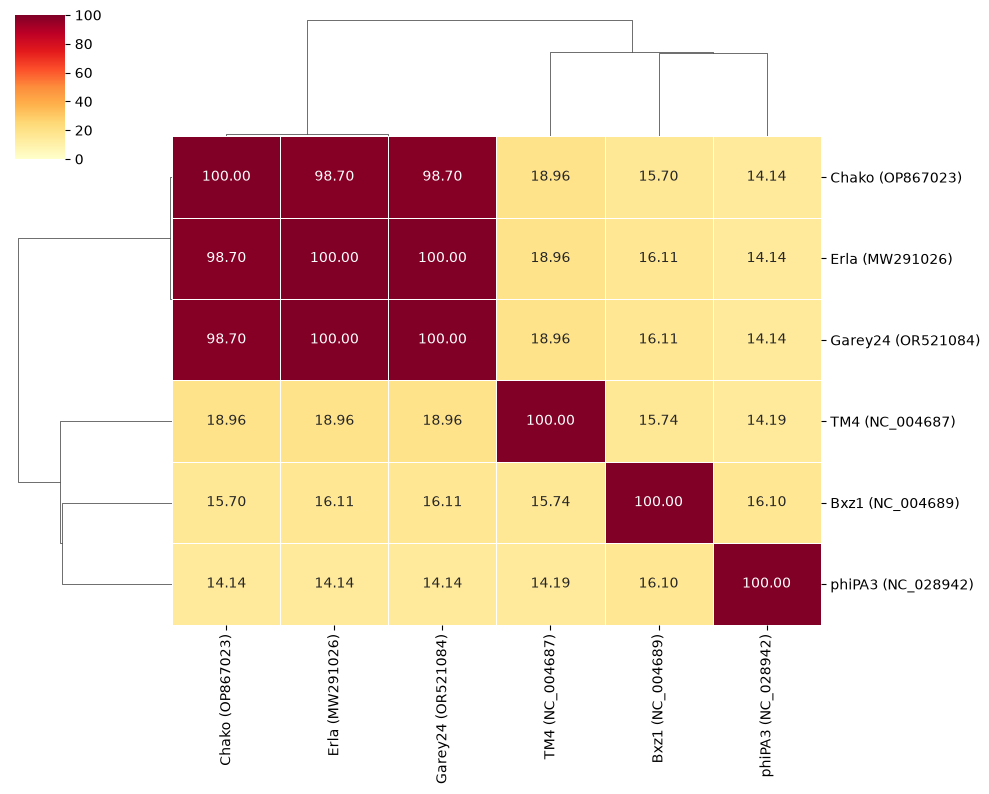

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt


# Generate a hierarchically clustered heatmap from the identity matrix
sns.clustermap(
    plot_matrix,

     # Sequential color scale for pairwise identity values
    cmap="YlOrRd",

    # Display identity values inside each cell
    annot=True,
    fmt=".2f",

    # Force a common scale across the full 0–100% identity range
    vmin=0,
    vmax=100,
    linewidths=0.5,
    figsize=(10, 8)
)

plt.show()

### Conclusions

The workflow successfully retrieved, screened, and compared a set of actinophage genomes using publicly available GenBank records and Biopython-based analyses.

Comparison of a conserved structural marker protein revealed two major similarity groups. Garey24 clustered closely with Chako and Erla, showing nearly identical structural marker protein sequences, whereas TM4, Bxz1, and phiPA3 formed a more distant group with substantially lower identity values.

Although based on a single protein marker and annotation-derived screening criteria, the analysis demonstrates how automated bioinformatics workflows can be used to organize, filter, and compare phage genomic datasets in a reproducible manner.